# setup for colab
it shall be ignored if it's a local run

In [1]:
# !pip install numpy scipy mujoco
# !git clone --branch hybrid_control https://github.com/JunningHuang/mj_ctrl.git
# %cd mj_ctrl

In [ ]:
import numpy as np
from scipy.linalg import pinv
import mujoco
from IPython.display import display, Math 
from utils import quick_plot, format_vector_to_latex, format_matrix_to_latex
import pinocchio as pino

# Prepare robot model and parameters

In [3]:
# Load the model and data.
xml_path = "kuka_iiwa_14/iiwa14.xml"
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)
# pino_model = pino.buildModelFromMJCF(xml_path)
# pino_data = pino_model.createData()

# --- Parameters ---
dt = 0.001
I = np.eye(model.nv)
model.opt.timestep = dt

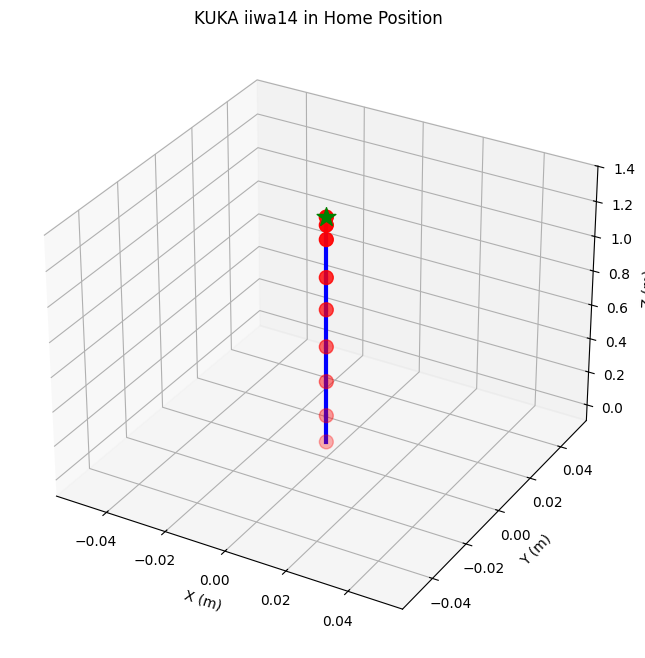

In [4]:
# Visualize!
quick_plot(model, data)

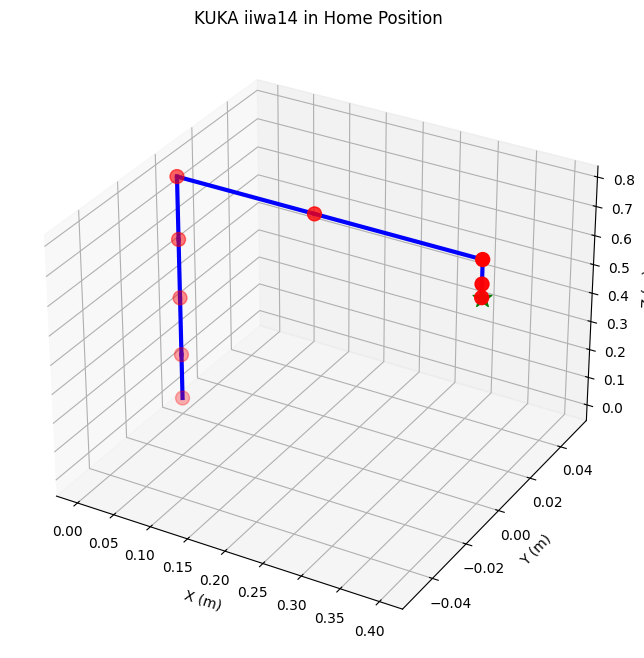

In [5]:
# Reset to "home" keyframe by name
key_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_KEY, "home")
mujoco.mj_resetDataKeyframe(model, data, key_id)
mujoco.mj_forward(model, data)

quick_plot(model, data)

In [6]:
# End-effector site we wish to control.
site_name = "attachment_site"
site_id = model.site(site_name).id

joint_names = [
    "joint1",
    "joint2",
    "joint3",
    "joint4",
    "joint5",
    "joint6",
    "joint7",
]
dof_ids = np.array([model.joint(name).id for name in joint_names])
actuator_ids = np.array([model.actuator(name).id for name in joint_names])

In [7]:
actuator_ids

array([0, 1, 2, 3, 4, 5, 6])

## Plot end-effector current status

In [8]:
# # --- 1. Current Simulation Time ---
# current_time = data.time
# print(f"Current Simulation Time: {current_time:.3f} seconds")

# # --- 2. Joint Positions (qpos) ---
# # data.qpos is a 1D numpy array representing the generalized coordinates.
# # For a pure revolute/prismatic joint robot, model.nq is the number of joints.
# # For a KUKA IIWA (7-DOF), model.nq will be 7.
# current_qpos = data.qpos
# print(f"\nJoint Positions (qpos, radians): {current_qpos}")
# print(f"Number of generalized coordinates (model.nq): {model.nq}")

# # If you want to see them in degrees:
# print(f"Joint Positions (qpos, degrees): {np.degrees(current_qpos).round(2)}")

# # --- 3. Joint Velocities (qvel) ---
# # data.qvel is a 1D numpy array representing the generalized velocities.
# # For a robot arm, model.nv is the number of joint velocities (same as model.nq for revolute/prismatic).
# current_qvel = data.qvel
# print(f"\nJoint Velocities (qvel, rad/s): {current_qvel}")
# print(f"Number of degrees of freedom (model.nv): {model.nv}")

# # --- 4. Joint Accelerations (qacc) ---
# # This is usually the result of the forward dynamics computation from applied torques.
# current_qacc = data.qacc
# print(f"\nJoint Accelerations (qacc, rad/s^2): {current_qacc}")

# # --- 5. Applied Control/Torques (ctrl) ---
# # This is where you write your control commands (joint torques, forces, etc.).
# # It's an input to the physics engine for the next step.
# current_ctrl = data.ctrl
# print(f"\nApplied Control/Torques (ctrl): {current_ctrl}")
# print(f"Number of control inputs (model.nu): {model.nu}")

# --- 6. End-Effector (EE) Position and Orientation ---
# To get the EE pose, you need to know its 'site ID' from your XML model.
EE_SITE_NAME = 'attachment_site'
ee_site_id = site_id

if ee_site_id != -1:
    ee_position = data.site_xpos[ee_site_id] # (x, y, z) position
    ee_orientation_matrix = data.site_xmat[ee_site_id].reshape(3, 3) # 3x3 rotation matrix
    print(f"\nEnd-Effector Position (site '{EE_SITE_NAME}'): {ee_position.round(4)} meters")
    print(f"End-Effector Orientation (rotation matrix from base to EE):\n{ee_orientation_matrix.round(4)}")
    # You can also convert to quaternion if needed:
    # from scipy.spatial.transform import Rotation as R
    # ee_orientation_quat = R.from_matrix(ee_orientation_matrix).as_quat()
    # print(f"End-Effector Orientation (quaternion xyzw): {ee_orientation_quat.round(4)}")
else:
    print(f"\nWarning: End-effector site '{EE_SITE_NAME}' not found. Cannot display its pose.")


End-Effector Position (site 'attachment_site'): [0.4   0.    0.654] meters
End-Effector Orientation (rotation matrix from base to EE):
[[ 1.  0. -0.]
 [ 0. -1.  0.]
 [-0. -0. -1.]]


# Compute stacked Jacobian Matrix
Reference:
1. Hierarchical Impedance-Based Tracking Control of Kinematically Redundant Robots: II.B Dynamically Consistent Null Space Projection. 

    This paper is reference 29 from Paper 2.

2. Hybrid force-impedance control for fast end-effector motions

$$
\begin{bmatrix}
\dot{\Phi} \\
\dot{x} \\
v
\end{bmatrix}
=
\underbrace{
\begin{bmatrix}
J_{\dot{\Phi}}(q) \\
J_{\dot{x}}(q) \\
J_v(q)
\end{bmatrix}
}_{\bar{J}(q)}
\dot{q}
\tag{9}
$$

The augmented Jacobian is defined as:

$$
J^{\text{aug}}_i(q) =
\begin{pmatrix}
J_1(q) \\
\vdots \\
J_i(q)
\end{pmatrix}
$$

In [9]:
"""
examples:
# Level 1 (Z-constraint): m1 = 1
J_aug_1 = J_constraint  # (1 × 7)

# Level 2 (XY-circle): m2 = 2  
J_aug_2 = np.vstack([J_constraint, J_circle])  # (3 × 7)

# Level 3 (Null space): m3 = 4
J_aug_3 = np.vstack([J_constraint, J_circle, J_null])  # (7 × 7) = full rank
"""

'\nexamples:\n# Level 1 (Z-constraint): m1 = 1\nJ_aug_1 = J_constraint  # (1 × 7)\n\n# Level 2 (XY-circle): m2 = 2  \nJ_aug_2 = np.vstack([J_constraint, J_circle])  # (3 × 7)\n\n# Level 3 (Null space): m3 = 4\nJ_aug_3 = np.vstack([J_constraint, J_circle, J_null])  # (7 × 7) = full rank\n'

The matrix N_i(q) is defined as:

$$
N_i(q) =
\begin{cases}
I, & \text{for } i = 1 \\
I - J^{\text{aug}}_{i-1}(q)^\top \left(J^{\text{aug}}_{i-1}(q)\right)^{M+, \top}, & \text{for } i = 2, \dots, r
\end{cases}
$$


The projected Jacobian is given by:

$$
\bar{J}_i(q)  = J_i(q) N_i(q)^\top
$$


- $J^{aug}_{i-1}$: Combined Jacobian of all higher-priority tasks (levels 1 to i-1)
- Takes the original task Jacobian J_i(q)
- Projects it through Ni​(q) to remove components that would affect higher-priority tasks
- Results in a "decoupled" Jacobian $\bar{J}_i$ that only affects task i without interfering with tasks 1 to i-1

## Computation Process: stacked Jacobian Matrix

In [10]:
# current Jacobi
jac = np.zeros((6, model.nv))
mujoco.mj_jacSite(model, data, jac[:3], jac[3:], site_id)
display(Math(format_matrix_to_latex(jac, "jac")))

<IPython.core.display.Math object>

In [11]:
M = np.zeros((model.nv, model.nv))
mujoco.mj_solveM(model, data, M, np.eye(model.nv))
display(Math(format_matrix_to_latex(M, "M")))

<IPython.core.display.Math object>

In [ ]:
"""
Compute Jacobian for table constraint (end-effector Z position)
J_Φ = ∂(z_ee)/∂q
"""
# This would be computed from forward kinematics
# For LWR IV+, extract Z-component of end-effector position Jacobian
J_full = jac  # (6, 7) for full pose
J_constraint = J_full[2:3, :]  # Extract Z-component row
display(Math(format_matrix_to_latex(J_constraint, "J_{constraint}")))

<IPython.core.display.Math object>

In [ ]:
"""
Compute Jacobian for circle drawing task (XY motion)
J_x = ∂([x_ee, y_ee])/∂q
"""
J_full = jac  # (6, 7)
J_circle = J_full[0:2, :]  # Extract X,Y components
display(Math(format_matrix_to_latex(J_circle, "J_{circle}")))

<IPython.core.display.Math object>

In [ ]:
def dynamically_consistent_pinv(J, M):
    """
    Compute dynamically consistent pseudoinverse
    J^{M+} = M^{-1} J^T (J M^{-1} J^T)^{-1}
    """
    M_inv = np.linalg.inv(M)
    temp = J @ M_inv @ J.T
    if np.linalg.det(temp) > 1e-6:  # Check singularity
        return M_inv @ J.T @ np.linalg.inv(temp)
    else:
        # Use regular pseudoinverse if singular
        return pinv(J)

In [ ]:
# def compute_null_space_projectors(M, J_constraint, J_circle):
#     """
#     Compute hierarchical null space projectors
#     N_i(q) = I - J_aug_{i-1}^{M+T} J_aug_{i-1}
#     """
    
#     # Level 1: Constraint (highest priority)
#     N1 = I  # N1 = I (no projection for highest priority)
    
#     # Level 2: Circle drawing (second priority)
#     J_aug1 = J_constraint  # Augmented Jacobian up to level 1
#     J_aug1_pinv = dynamically_consistent_pinv(J_aug1, M)
#     N2 = I - J_aug1_pinv @ J_aug1
    
#     # Level 3: Null space (lowest priority)
#     J_aug2 = np.vstack([J_constraint, J_circle])  # Stack constraints
#     J_aug2_pinv = dynamically_consistent_pinv(J_aug2, M)
#     N3 = I - J_aug2_pinv @ J_aug2
        
#     return N1, N2, N3, J_constraint, J_circle

"""
Compute hierarchical null space projectors
N_i(q) = I - J_aug_{i-1}^{M+T} J_aug_{i-1}
"""

# Level 1 can use all 7 DOF freely (highest priority)
N1 = I  # N1 = I (no projection for highest priority)

In [ ]:
# Level 2: Circle drawing (second priority)
J_aug1 = J_constraint  # Augmented Jacobian up to level 1
J_aug1_pinv = dynamically_consistent_pinv(J_aug1, M)
# N₂: Projects out the Z-constraint direction, leaving 6 DOF for circle drawing
N2 = I - J_aug1_pinv @ J_aug1
display(Math(format_matrix_to_latex(N2, "N2")))

<IPython.core.display.Math object>

In [ ]:
I.shape

(7, 7)

In [ ]:
# Level 3: Null space (lowest priority)
J_aug2 = np.vstack([J_constraint, J_circle])  # Stack constraints
display(Math(format_matrix_to_latex(J_aug2, "J_{aug2}")))
J_aug2_pinv = dynamically_consistent_pinv(J_aug2, M)
# N₃: Projects out both Z-constraint AND XY-circle, leaving 4 DOF for secondary tasks
N3 = I - J_aug2_pinv @ J_aug2
display(Math(format_matrix_to_latex(N3, "N3")))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
"""
Compute hierarchically decoupled Jacobians
J̄_i(q) = J_i(q) N_i(q)^T
"""

# Decoupled Jacobians
J_bar1 = J_constraint @ N1.T  # Constraint task (2 x 7) @ (7 x 7)
J_bar2 = J_circle @ N2.T      # Circle drawing task
display(Math(format_matrix_to_latex(J_bar1, "J_{bar1}")))
display(Math(format_matrix_to_latex(J_bar2, "J_{bar2}")))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### change base of null space

This problem can be overcome by considering an Z(q) (n x r), where J is J_task, such that:

$$
JZ = 0,
$$

and introducing an (r x 1) velocity vector v, such that:

$$
\dot{q}_n = N\dot{q} = Z\nu. \tag{16}
$$

r = n - m (m is dimension of task space)

J_task * Z = 0

Z means a matrix whose columns form a basis for the null space.

In [41]:
"""
Compute Z(q) matrix such that J_task @ Z = 0, J_task is J_aug2 here

Args:
    J_task: Combined task Jacobian (e.g., J_aug_2 which is 3×7)

Returns:
    Z: Null space basis matrix (7×4)
"""

# Method 1: SVD approach (most robust)
U, s, Vt = np.linalg.svd(J_aug2)

display(Math(format_matrix_to_latex(Vt, "Vt")))
display(Math(format_vector_to_latex(s, "s")))
# Null space is spanned by the last (n - rank) columns of V^T
rank = np.sum(s > 1e-10)  # Numerical rank
print(f"rank: {rank}")
null_space_dim = J_aug2.shape[1] - rank  # n - m
print(f"null space dimension: {null_space_dim}" )

Z = Vt[rank:, :].T  # (7 × 4) - last 4 columns of V^T transposed
display(Math(format_matrix_to_latex(Z, "Z")))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

rank: 3
null space dimension: 4


<IPython.core.display.Math object>

In [42]:
# For null space, we need to define what we want to control
# e.g., joint positions for joint limit avoidance
J_null = Z.T # (4×7)
J_bar3 = J_null @ N3.T  
display(Math(format_matrix_to_latex(J_bar3, "J_{bar3}")))

<IPython.core.display.Math object>

### verify z 
Jconstraint*​Z=0_1×4

​Jcircle*Z=0_2×4

In [43]:
display(Math(format_matrix_to_latex(J_constraint @ Z, "J_{constraint} * Z")))
display(Math(format_matrix_to_latex(J_circle @ Z, "J_{circle} * Z")))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [44]:
def hierarchical_impedance_jacob(jac_list: list, dim, M):
    # draw circle: only 2 subspace jac can be defined,
    # last one - null space, there is no jac, it has to be calculated
    Ns = []
    I = np.eye(dim)
    J_aug = np.empty((0, dim))
    Ns.append(I)
    for i, jac in enumerate(jac_list):
        J_aug = np.vstack([J_aug, jac_list[i]])
        J_aug_inv = dynamically_consistent_pinv(J_aug, M)
        N = I - J_aug_inv @ J_aug
        Ns.append(N)
    
    U, s, Vt = np.linalg.svd(J_aug)
    rank = np.sum(s > 1e-10)
    J_null = Vt[rank:, :]
    jac_list.append(J_null)
    
    J_bars = []
    for N, jac in zip(Ns, jac_list):
        J_bar = jac @ N.T
        J_bars.append(J_bar)
    return Ns, J_bars

jac_list = [J_constraint, J_circle]
dim = model.nv
Ns, J_bars=hierarchical_impedance_jacob(jac_list, dim, M)
i = 0
for N, jac in zip(Ns, J_bars):
    display(Math(format_matrix_to_latex(N, f"N_{i}")))
    display(Math(format_matrix_to_latex(jac, f"J_{i}")))
    i+=1

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Define circle task and get desired kinematic variables

In [45]:
t = 0

In [46]:
# Circle trajectory
circle_center = np.array([0.3, 0.0])
circle_radius = 0.1
table_height = 0.654
omega = 0.5

# def circle_trajectory(t):
# Position (circle parametric equations)
x_desired = np.array([
    circle_center[0] + circle_radius * np.cos(omega * t),
    circle_center[1] + circle_radius * np.sin(omega * t)
])

# Velocity (first derivative)
x_dot_desired = np.array([
    -circle_radius * omega * np.sin(omega * t),
    circle_radius * omega * np.cos(omega * t)
])

# Acceleration (second derivative)
x_ddot_desired = np.array([
    -circle_radius * omega**2 * np.cos(omega * t),
    -circle_radius * omega**2 * np.sin(omega * t)
])


# Control Force

In [47]:
J_phi = J_bar1
J_x = J_bar2
J_v = J_bar3

## Unassigned variables

| Parameter                  | Simulation        | Experiments       |
|---------------------------|-------------------|-------------------|
| Transl. Cart. impedance   | 5000 [N/m]        | 1500 [N/m]        |
| Rot. Cart. impedance      | 500 [Nm/rad]      | 300 [Nm/rad]      |
| Damping ratio             | 0.7               | 0.7               |


The desired task-space translational and rotational stiffness and damping values used in simulation and experiments

In [48]:
# TODO: how to get following measured values from mujoco
g = None # not in use?
C = pino.computeCoriolisMatrix(pino_model, pino_data, data.qpos, data.qvel) 
F_ext_x = None
F_ext_v = None

# TODO: how to get differential value of Jacobimatrix?
J_phi_dot = None

NameError: name 'pino' is not defined

In [ ]:
# Positive value = downward force (into the table)
F_desired_contact = np.array([5.0])   # 5N downward

## Motion space control force

The control force in the motion space is given by:

$$
F^{\text{ctrl}}_{x} = M_{x} \ddot{x}^{\text{des}} + C_{x} \dot{x}^{\text{des}} - K_{x} \tilde{x} - D_{x} \dot{\tilde{x}}.
\tag{16}
$$


In [ ]:
# translational Cartesian impedance
# task space
k_x_stiffness = 5000  # N/m (higher stiffness for precise tracking)
k_y_stiffness = 5000  # N/m (same for both XY directions)
K_x = np.diag([k_x_stiffness, k_y_stiffness])  # (2×2)
# TODO: Dx
D_x = None

how to get Mx

In [49]:
# approach 1
M_inv = np.zeros((model.nv, model.nv))
mujoco.mj_solveM(model, data, M_inv, np.eye(model.nv))
Mx_inv = jac @ M_inv @ jac.T
if abs(np.linalg.det(Mx_inv)) >= 1e-2:
    Mx = np.linalg.inv(Mx_inv)
else:
    Mx = np.linalg.pinv(Mx_inv, rcond=1e-2)

display(Math(format_matrix_to_latex(Mx, "Mx_{1}")))

<IPython.core.display.Math object>

In [50]:
# approach 2
M = np.zeros((model.nv, model.nv))
mujoco.mj_fullM(model, M, data.qM)
Mx = jac @ M @ jac.T

display(Math(format_matrix_to_latex(Mx, "Mx_{2}")))

<IPython.core.display.Math object>

In [ ]:
M_inv = np.linalg.inv(M)
C_inv = np.linalg.inv(C)

In [ ]:
M_x = np.linalg.inv(J_x @ M_inv @ J_x.T)
C_x = np.linalg.inv(J_x @ C_inv @ J_x.T)

In [ ]:
current_pos_3d = data.site_xpos[site_id]
x_current = current_pos_3d[0:2]

# motion-space velocity: x_dot = J * q_dot
q_dot = data.qvel.copy()
site_vel_6d = jac @ q_dot  # (6,) - [vx, vy, vz, wx, wy, wz]
x_dot_current = site_vel_6d[0:2]  # XY velocity

In [ ]:
# Errors
x_tilde = x_current - x_desired
x_dot_tilde = x_dot_current - x_dot_desired
F_ctrl_x = (M_x @ x_ddot_desired + 
            C_x @ x_dot_desired - 
            K_x @ x_tilde - 
            D_x @ x_dot_tilde)

## Null space control force
$$
F^{\text{ctrl}}_v = -k(q_v - q_{v,d}) - d\dot{q}_v
$$

Hybrid Force-Impedance Control for Fast End-Effector Motions, footnote 5

q_v means velocity of joint space?

In [ ]:
# TODO: get F_ctrl_v

## Constraint space force control

The constraint direction control force update is given by:

$$
F_{\Phi}^{\text{ctrl}} = F_{\Phi}^{\text{des}} 
- {\Lambda}_{\Phi}J_{\Phi} M^{-1} 
\left(J_{x}^{\top} F_{x}^{\text{ctrl}} + J_{v}^{\top} F_{v}^{\text{ctrl}}\right) 
+ {\Lambda}_{\Phi}J_{\Phi} M^{-1} 
\left(J_{x}^{\top} F_{x}^{\text{ext}} + J_{v}^{\top} F_{v}^{\text{ext}}\right) 
+ {\Lambda}_{\Phi}
\left(J_{\Phi}M^{-1} C - \dot{J}_{\Phi}\right) \dot{q}
\tag{19}
$$

- $J_{x}^{\top} F_{x}^{\text{ctrl}} + J_{v}^{\top} F_{v}^{\text{ctrl}}$​ - "Joint Torques from Other Tasks"
- M−1(⋯) - "Joint Accelerations from Other Tasks" - $\dot{q}$
- JΦ​M−1(⋯) - "Constraint Acceleration from Other Tasks" - a
- ΛΦ​JΦ​M−1(⋯) - "Constraint Force Needed to Cancel Coupling" - Λ is mass in cartesian space

In [ ]:
lambda_phi = np.linalg.inv(J_phi @ M_inv @ J_phi.T)

In [ ]:
F_ctrl_constraint = (
        lambda_phi @ F_desired_contact -
        lambda_phi @ J_phi @ M_inv @ (J_x.T @ F_ctrl_x + J_v.T @ F_ctrl_v) +
        lambda_phi @ J_phi @ M_inv @ (J_x.T @ F_ext_x + J_v.T @ F_ext_v) +
        lambda_phi @ (J_phi @ M_inv @ C - J_phi_dot) @ q_dot
    )

# C = data.qfrc_bias.reshape(-1, 1)?